# Titanic Exercise

to install seaborn :
```bash
conda install -c conda-forge seaborn
````


In [1]:
import pandas as pd
from seaborn import load_dataset
import matplotlib.pyplot as plt
import numpy as np

In [2]:
embarked_labels = {
  "C": "Cherbourg",
  "Q": "Queenstown",
  "S": "Southampton",
}

In [3]:
# 1. Load the dataset
titanic = load_dataset("titanic")
titanic


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
titanic.info()
titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# 2. Data cleaning
# 2.1. Check the missing values
print(titanic.shape)
print(titanic.isnull().sum())

# 2.2. Replace the missing values in age with the mean
titanic["age"].fillna(titanic.age.mean(), inplace=True)

# 2.3 Drop the unused columns
titanic.drop(columns=["deck", "who", "embark_town", "class"], inplace=True)

# 2.4 Drop the rows with missing values in embarked
titanic.dropna(subset=["embarked"], inplace=True)

print(titanic.shape)
print(titanic.isnull().sum())


(889, 11)
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alive         0
alone         0
dtype: int64


/var/folders/w3/5hy6_w9d52l2jjrccrpq3z0h0000gn/T/ipykernel_49111/1897988734.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["age"].fillna(titanic.age.mean(), inplace=True)


KeyError: "['deck', 'who', 'embark_town', 'class'] not found in axis"

In [79]:
# 3 Analyse data
# 3.1 Calculate the overall survival rate of the Titanic passengers
survival_rate = titanic.survived.sum() / titanic.shape[0] * 100
survival = pd.Series([survival_rate, 100-survival_rate], index=["Survived", "Died"])

titanic.survived.value_counts(normalize=True) * 100

titanic.survived.mean()

np.float64(0.38245219347581555)

In [30]:
# 3.2 Analyze the distribution of passengers by class (Pclass) and by port of embarkation (Embarked).
#titanic.groupby(["pclass", "embarked"]).survived.agg([len, np.mean])
#titanic.groupby(["pclass", "embarked"]).survived.count()
# titanic.groupby(["pclass"]).embarked.value_counts()
distribution_by_class_and_port = titanic.groupby(["embarked", "pclass"]).size().reset_index(name="count")
# distribution_by_class_and_port.groupby("pclass").transform('sum')
distribution_by_class_and_port["percent_class"] = distribution_by_class_and_port["count"] / distribution_by_class_and_port.groupby("pclass")["count"].transform('sum') * 100

distribution_by_class_and_port["percent_port"] = distribution_by_class_and_port["count"] / distribution_by_class_and_port.groupby("embarked")["count"].transform('sum') * 100

distribution_by_class_and_port


,embarked,pclass,count,percent_class,percent_port
0,C,1,85,39.719626,50.595238
1,C,2,17,9.239130,10.119048
2,C,3,66,13.441955,39.285714
3,Q,1,2,0.934579,2.597403
4,Q,2,3,1.630435,3.896104
5,Q,3,72,14.663951,93.506494
6,S,1,127,59.345794,19.720497
7,S,2,164,89.130435,25.465839
8,S,3,353,71.894094,54.813665


In [34]:
# 3.3 Calculate the proportion of male and female passengers
titanic.sex.value_counts(normalize=True) * 100

sex
male      64.904387
female    35.095613
Name: proportion, dtype: float64

<Axes: title={'center': 'Age distribution'}, xlabel='age'>

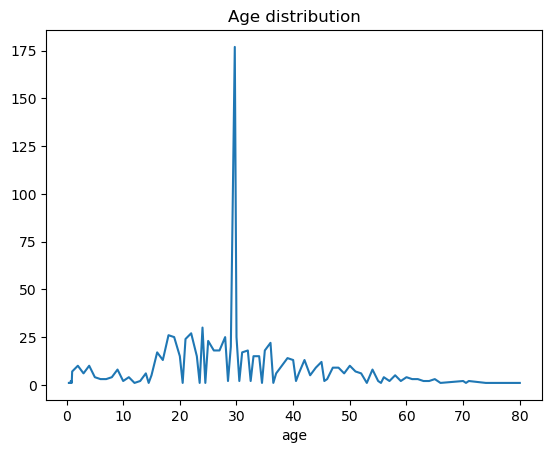

In [39]:
# 3.4 Identify the age distribution of passengers and find the most represented age categories.
titanic.age.value_counts().sort_index().plot(title="Age distribution")

<Axes: xlabel='age_cutted'>

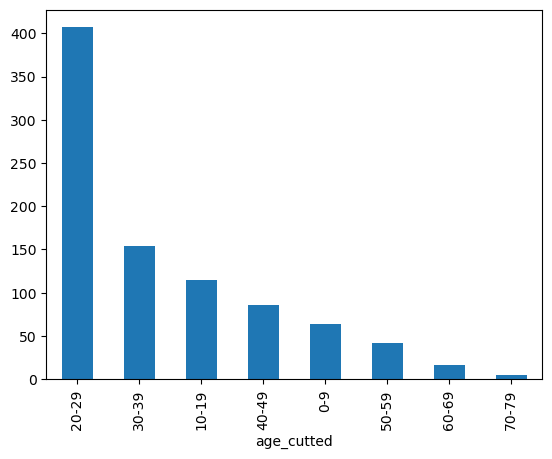

In [51]:
age_bins = list(range(0, 81, 10))
age_label = [f"{i*10}-{i*10+9}" for i in range(80//10)]

titanic["age_cutted"] = pd.cut(titanic.age, bins=age_bins, labels=age_label)
titanic.age_cutted.value_counts().plot(kind="bar")

<Axes: xlabel='pclass'>

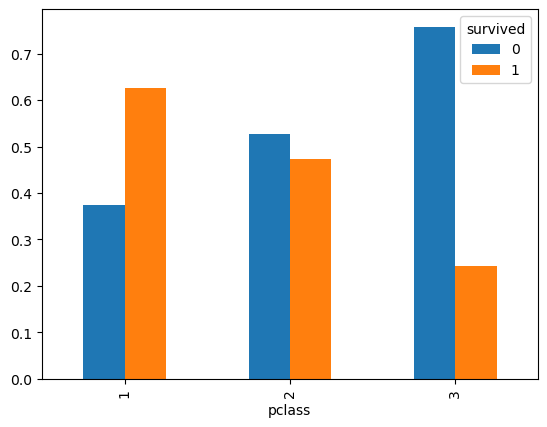

In [64]:
# 4 Alives analyse
# 4.1 Analyze survival based on ticket class (Pclass).
# titanic.groupby(["pclass", "survived", "sex"]).age.agg([len])

titanic.groupby("pclass").survived.value_counts(normalize=True).unstack().plot(kind="bar")

In [68]:
# 4.2 Analyze survival based on gender (Sex).
titanic.groupby("sex").survived.value_counts(normalize=True)


sex     survived
female  1           0.740385
        0           0.259615
male    0           0.811092
        1           0.188908
Name: proportion, dtype: float64

<Axes: xlabel='pclass,sex'>

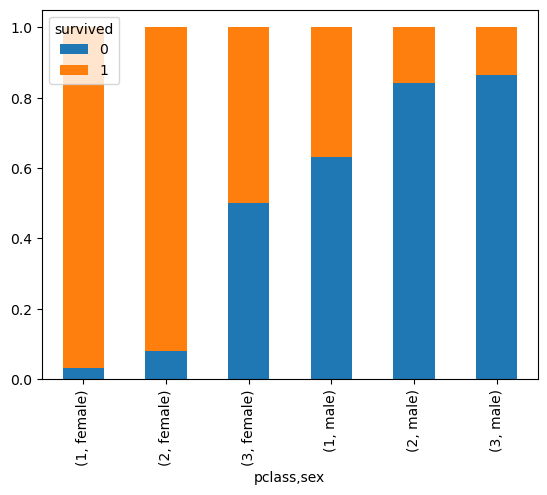

In [73]:
titanic.groupby(["pclass", "sex"]).survived\
.value_counts(normalize=True)\
.unstack().sort_index(level=[1])\
.plot.bar(stacked=True)

/var/folders/w3/5hy6_w9d52l2jjrccrpq3z0h0000gn/T/ipykernel_49111/862389717.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby("age_cutted").survived.value_counts().unstack().plot(kind="bar", stacked=True)


<Axes: xlabel='age_cutted'>

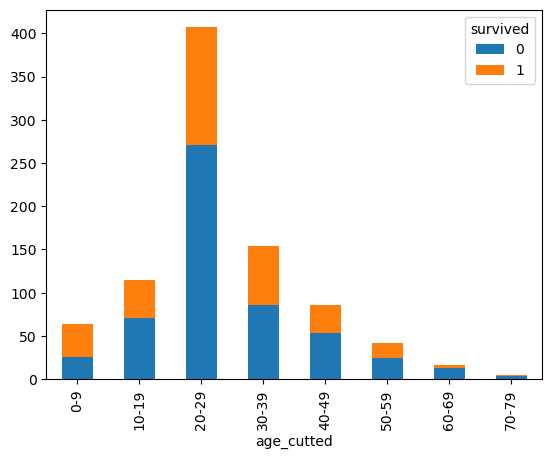

In [77]:
# 4.3
titanic.groupby("age_cutted").survived.value_counts().unstack().plot(kind="bar", stacked=True)

In [78]:
# 4.4 Analyze survival based on port of embarkation (Embarked).
titanic.groupby('embarked')['survived'].value_counts(normalize=True).unstack() * 100

survived,0,1
embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


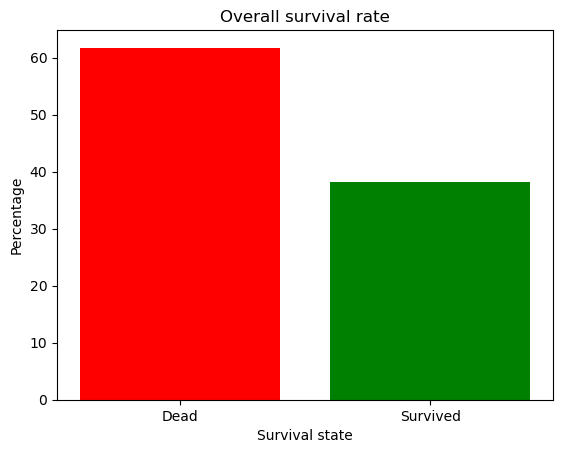

In [82]:
# 5 Plottings
# 5.1 Create a bar chart (plt.bar) to visualize the overall survival rate.
state: list[str] = ["Dead", "Survived"]
plt.bar(state, [100-survival_rate, survival_rate], color=["r", "g"])
plt.title("Overall survival rate")
plt.xlabel("Survival state")
plt.ylabel("Percentage")
plt.show()

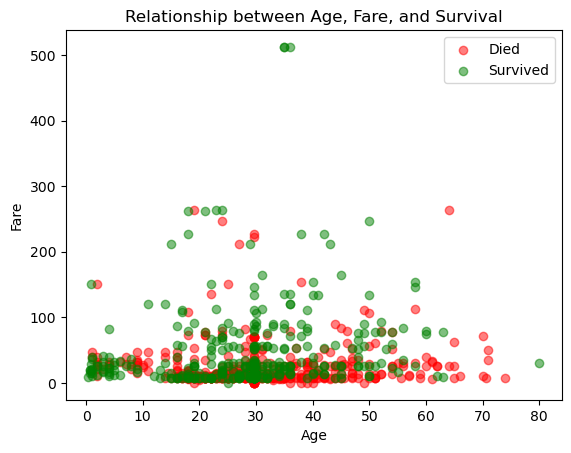

In [89]:


plt.scatter(
  titanic.loc[titanic.survived == 0].age, 
  titanic.loc[titanic.survived == 0].fare,
  c="r", label="Died", alpha=0.5
)

plt.scatter(
  titanic.loc[titanic.survived == 1].age, 
  titanic.loc[titanic.survived == 1].fare,
  c="g", label="Survived", alpha=0.5
)

plt.title('Relationship between Age, Fare, and Survival')
plt.legend()
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

/var/folders/w3/5hy6_w9d52l2jjrccrpq3z0h0000gn/T/ipykernel_49111/662937587.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


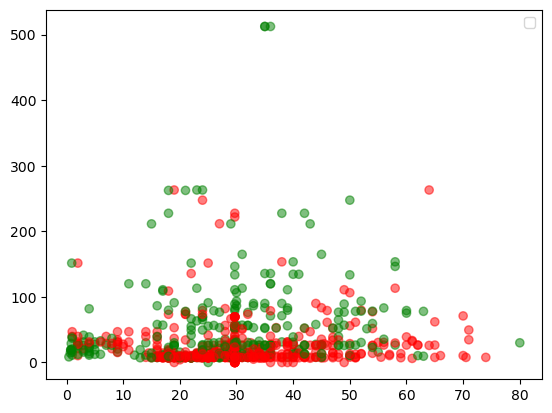

In [96]:
plt.scatter(
  titanic.age, titanic.fare, 
  c=titanic.survived.map({0: "red", 1: "green"}),
  alpha=0.5
)

plt.legend()

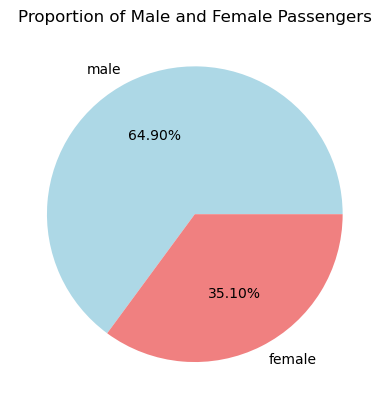

In [105]:
# 5.4 Produce a pie chart to show the proportion of male and female passengers
x = titanic.sex.value_counts()
plt.pie(x, labels=x.index, autopct="%.2f%%", colors=["lightblue", "lightcoral"])
plt.title('Proportion of Male and Female Passengers')
plt.show()

<Axes: xlabel='embarked'>

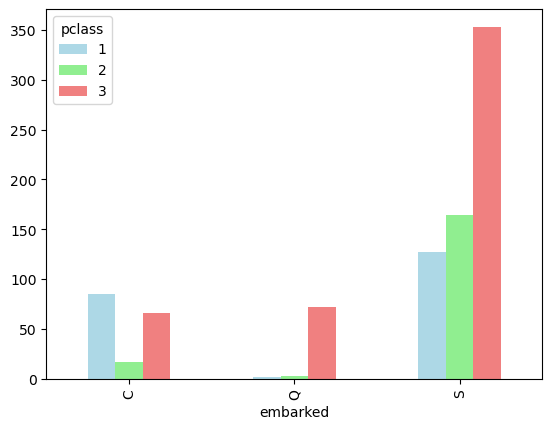

In [110]:
class_port = titanic.groupby(["embarked", "pclass"]).size().unstack()
class_port.plot(kind="bar", color=["lightblue", "lightgreen", "lightcoral"])

embarked,C,Q,S
pclass,,,
1,85,2,127
2,17,3,164
3,66,72,353


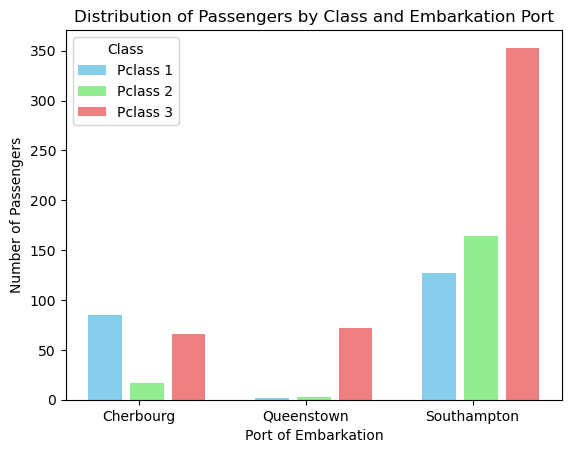

In [113]:
distribution_by_class_embarked = titanic.groupby(['pclass', 'embarked']).size().unstack()
display(distribution_by_class_embarked)

fig, ax = plt.subplots()
width = 0.2
class_labels = distribution_by_class_embarked.columns.map(embarked_labels.get)
enu: list[tuple[int, tuple[int, str]]] = enumerate(zip(distribution_by_class_embarked.index, ["skyblue", "lightgreen", "lightcoral"]))
for i, (pclass, color) in enu:
  positions: list[float] = list(range(len(class_labels))) if i==0 else [pos + width + 0.05 for pos in positions]
  plt.bar(positions, distribution_by_class_embarked.loc[pclass], width=width, label=f'Pclass {pclass}', color=color)

# Adding labels and title
plt.title('Distribution of Passengers by Class and Embarkation Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')
plt.xticks([pos + width for pos in range(len(class_labels))], class_labels)
plt.legend(title='Class')

# Show the plot
plt.show()

,age,fare,pclass,sibsp,parch,survived,gender
age,1.000000,0.088604,-0.327954,-0.231875,-0.178232,-0.074673,-0.089434
fare,0.088604,1.000000,-0.548193,0.160887,0.217532,0.255290,0.179958
pclass,-0.327954,-0.548193,1.000000,0.081656,0.016824,-0.335549,-0.127741
sibsp,-0.231875,0.160887,0.081656,1.000000,0.414542,-0.034040,0.116348
parch,-0.178232,0.217532,0.016824,0.414542,1.000000,0.083151,0.247508
survived,-0.074673,0.255290,-0.335549,-0.034040,0.083151,1.000000,0.541585
gender,-0.089434,0.179958,-0.127741,0.116348,0.247508,0.541585,1.000000


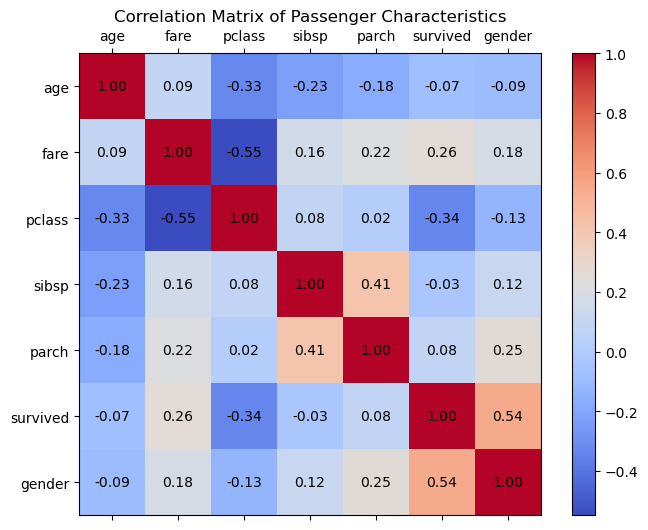

In [114]:
# 6 Bonus for the datascients experts ;P

# 6.1 Examine the correlation between different passenger characteristics to identify meaningful relationships.
# Select relevant columns for correlation analysis
correlation_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived', 'gender']

titanic['gender'] = titanic['sex'].map({'male': 0, 'female': 1})
# Create a correlation matrix
correlation_matrix = titanic[correlation_columns].corr()
display(correlation_matrix)

# Create a basic heatmap using Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(correlation_matrix, cmap='coolwarm')
fig.colorbar(cax)

# Set labels
ax.set_xticks(np.arange(len(correlation_columns)))
ax.set_yticks(np.arange(len(correlation_columns)))
ax.set_xticklabels(correlation_columns)
ax.set_yticklabels(correlation_columns)

# Display the correlation values
for i in range(len(correlation_columns)):
  for j in range(len(correlation_columns)):
    text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

# Set title
plt.title('Correlation Matrix of Passenger Characteristics')

# Show the plot
plt.show()

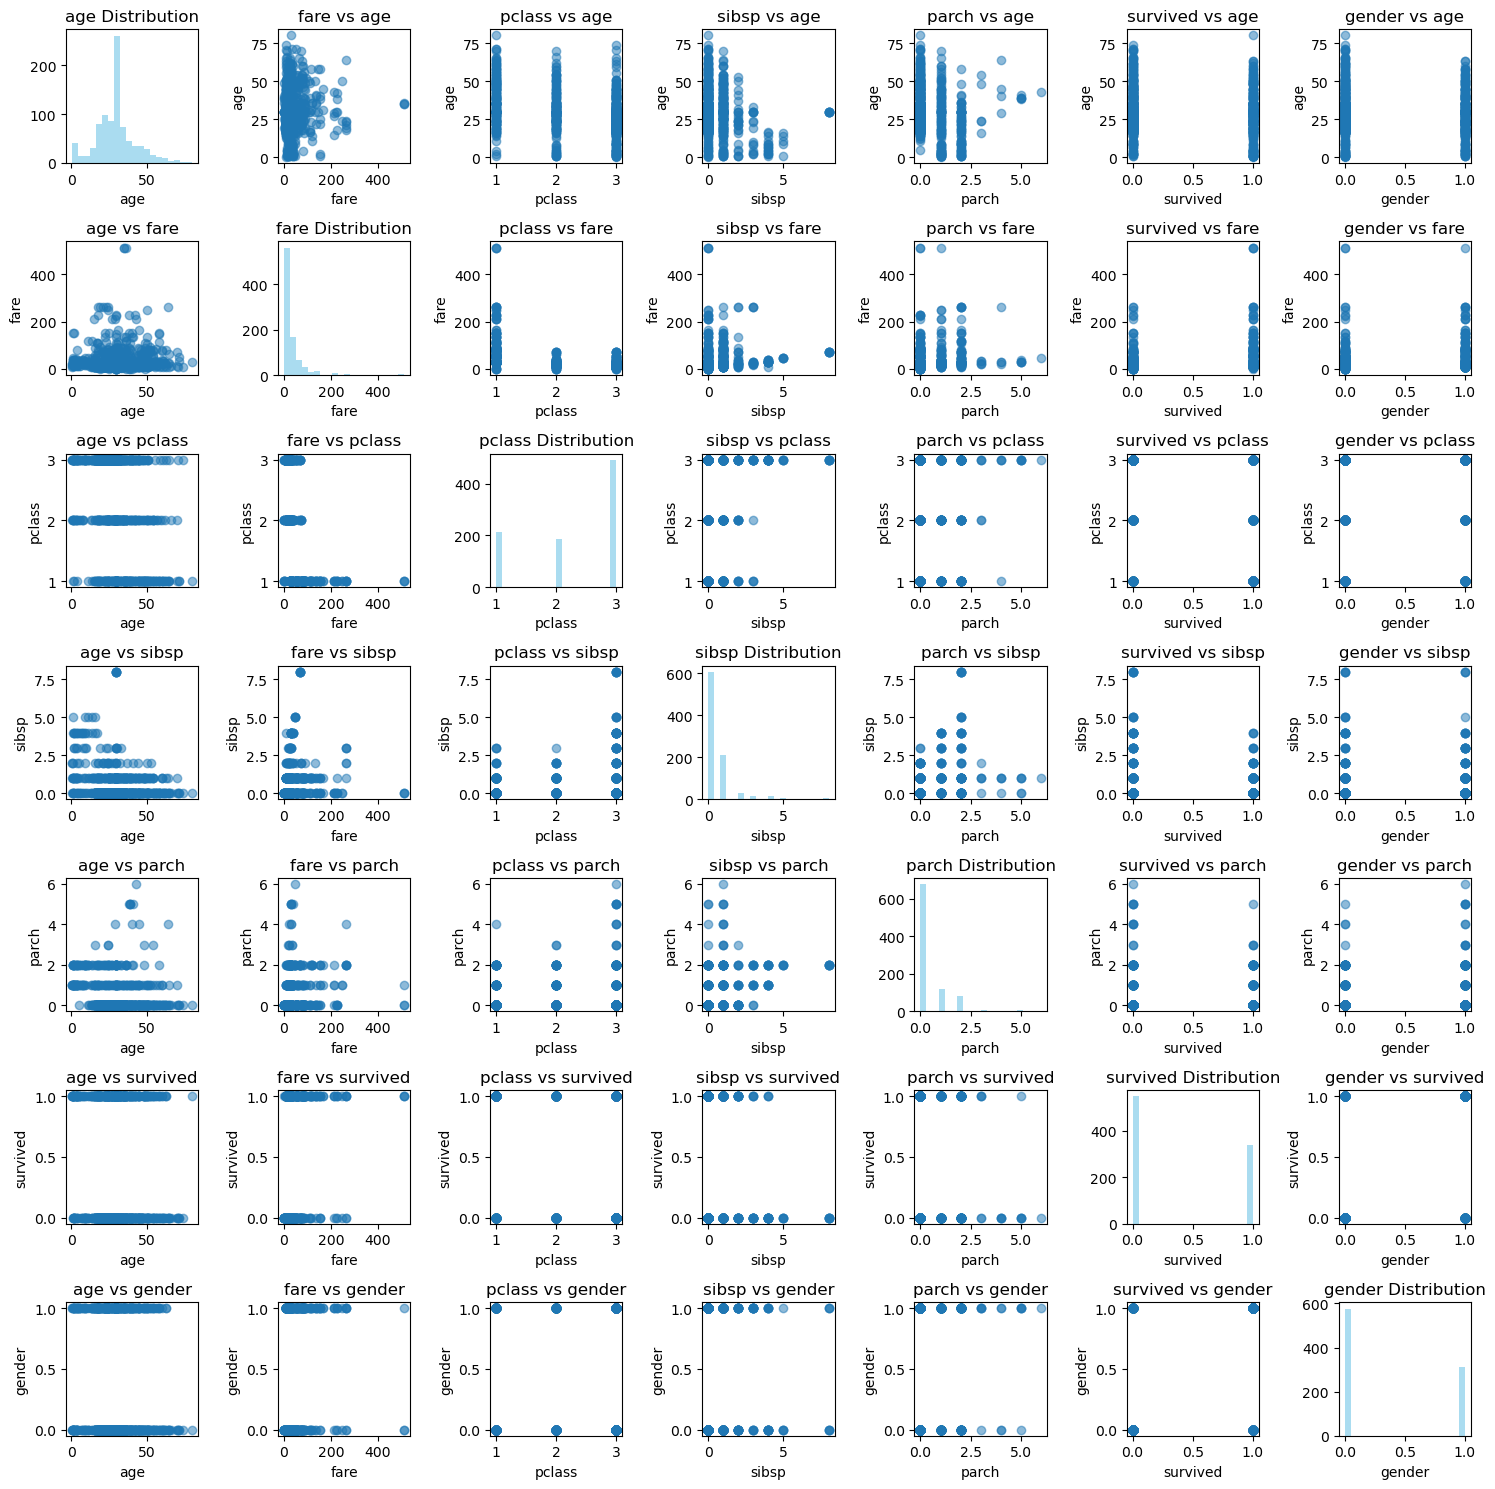

In [115]:
import numpy as np

# Select relevant numerical columns
numerical_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived', 'gender']

# Create a matrix of scatter plots
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=len(numerical_columns), figsize=(15, 15))

for i in range(len(numerical_columns)):
    for j in range(len(numerical_columns)):
        if i == j:
            axes[i, j].hist(titanic[numerical_columns[i]], bins=20, color='skyblue', alpha=0.7)
            axes[i, j].set_title(f'{numerical_columns[i]} Distribution')
            axes[i, j].set_xlabel(numerical_columns[i])
        else:
            axes[i, j].scatter(titanic[numerical_columns[j]], titanic[numerical_columns[i]], alpha=0.5)
            axes[i, j].set_title(f'{numerical_columns[j]} vs {numerical_columns[i]}')
            axes[i, j].set_xlabel(numerical_columns[j])
            axes[i, j].set_ylabel(numerical_columns[i])

# Adjust layout
plt.tight_layout()
plt.show()